<a href="https://colab.research.google.com/github/SophieLya/Data-Mining/blob/main/Latihan_1_Pengantar_Data_Analyst_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1️⃣ Question

Pertanyaan analisis:

1. Berapa jumlah total penduduk dan tenaga kesehatan di Jawa Tengah?

2. Rasio perbandingan setiap jenis tenaga kesehatan di Jawa Tengah?

3. Daerah mana saja yang rasio dokter dan penduduk sudah mencukupi (1 dokter per 1.000 penduduk)?

# 2️⃣ Data Wrangling

In [ ]:
import pandas as pd

# Membaca file excel
df = pd.read_excel('/content/drive/MyDrive/Dian Folder/Materi - Data Analyst/Camp 01 - Data Analyst/Materi 1 - Pengantar Data Analyst/Modul Praktik/jumlah-tenaga-kesehatan-tahun-2022.xlsx')

# Melihat 5 baris pertama
print(df.head())

# Mengecek informasi dataset
print(df.info())

# Mengecek apakah ada missing values
print(df.isnull().sum())

# Mengecek duplikasi data
print("Jumlah duplikasi data:", df.duplicated().sum(), "\n")

# Menampilkan data yang duplikat (misal kasus kabupaten Demak)
duplikat = df[df.duplicated(keep=False)]
print("Data duplikat:")
print(duplikat, "\n")

# Menghapus kolom duplikat jika ada dan menghapus duplikasi baris
df = df.drop_duplicates()


  tipe    kabupaten_kota  jumlah_penduduk  jumlah_tenaga_gizi  \
0  Kab       Kab.Cilacap          1988622                  93   
1  Kab      Kab.Banyumas          1806013                 157   
2  Kab   Kab.Purbalingga          1019840                  58   
3  Kab  Kab.Banjarnegara          1038718                  97   
4  Kab       Kab.Kebumen          1376825                  93   

   jumlah_tenaga_kefarmasian  jumlah_bidan  jumlah_perawat  \
0                        369          1264            2140   
1                        566          1325            3558   
2                        264           733            1355   
3                        225           796            1071   
4                        438          1244            1965   

   jumlah_dokter_gigi  jumlah_dokter_spesialis  jumlah_dokter_umum  
0                  58                      107                 289  
1                 128                      349                 566  
2                  36        

🔹Insight

* Dataset lengkap: `36 baris`, `10 kolo`m, tanpa missing values.

* Terdapat 1 `duplikasi` di Kab. Demak → perlu dihapus agar analisis akurat.

* Distribusi tenaga kesehatan `tidak merata` antar kabupaten/kota.

* Rasio tenaga kesehatan terhadap penduduk berbeda-beda: beberapa kabupaten kecil punya rasio lebih baik meski jumlah tenaga kesehatan lebih sedikit.

* Data siap dianalisis lebih lanjut atau divisualisasi untuk melihat kabupaten yang kekurangan tenaga kesehatan.

# 3️⃣ Exploratory Data Analysis (EDA)

## 1. Berapa jumlah total penduduk dan tenaga kesehatan di Jawa Tengah?

In [ ]:
import pandas as pd

# Tentukan kolom tenaga kesehatan
jenis_tenaga = [
    'jumlah_tenaga_gizi',
    'jumlah_tenaga_kefarmasian',
    'jumlah_bidan',
    'jumlah_perawat',
    'jumlah_dokter_gigi',
    'jumlah_dokter_spesialis',
    'jumlah_dokter_umum'
]

# 1. Tambahkan kolom total tenaga kesehatan per kabupaten (jumlah per baris)
df['total_tenaga'] = df[jenis_tenaga].sum(axis=1)

# 2. Hitung total penduduk dan total tenaga kesehatan
total_penduduk = df['jumlah_penduduk'].sum()
total_tenaga = df['total_tenaga'].sum()

print(f"Total penduduk Jawa Tengah: {total_penduduk:,} jiwa")
print(f"Total tenaga kesehatan Jawa Tengah: {total_tenaga:,} orang\n")

# 3. Tambahkan baris total per kolom (total setiap jenis tenaga dan penduduk)
total_keseluruhan = df[jenis_tenaga + ['jumlah_penduduk', 'total_tenaga']].sum()
total_keseluruhan['kabupaten_kota'] = 'Total'

# Gabungkan baris total ke DataFrame
df = pd.concat([df, pd.DataFrame([total_keseluruhan])], ignore_index=True)

# Tampilkan hasil
print(df)

# Tampilkan total tenaga per kabupaten
df_per_kabupaten = df[['kabupaten_kota', 'total_tenaga']]
print("Total tenaga kesehatan per kabupaten:")
print(df_per_kabupaten)

# Hitung total tenaga kesehatan per jenis di seluruh Jawa Tengah
total_per_jenis = df[jenis_tenaga].sum()
print("\nTotal tenaga kesehatan berdasarkan jenis di Jawa Tengah:")
print(total_per_jenis)

Total penduduk Jawa Tengah: 37,032,410 jiwa
Total tenaga kesehatan Jawa Tengah: 124,757 orang

    tipe    kabupaten_kota  jumlah_penduduk  jumlah_tenaga_gizi  \
0    Kab       Kab.Cilacap          1988622                  93   
1    Kab      Kab.Banyumas          1806013                 157   
2    Kab   Kab.Purbalingga          1019840                  58   
3    Kab  Kab.Banjarnegara          1038718                  97   
4    Kab       Kab.Kebumen          1376825                  93   
5    Kab     Kab.Purworejo           778257                  63   
6    Kab      Kab.Wonosobo           896346                  57   
7    Kab      Kab.Magelang          1312573                  68   
8    Kab      Kab.Boyolali          1079952                  74   
9    Kab        Kab.Klaten          1275850                 130   
10   Kab     Kab.Sukoharjo           916627                  93   
11   Kab      Kab.Wonogiri          1057087                  84   
12   Kab   Kab.Karanganyar        

🔹Insight

* Total penduduk: `37.032.410 jiwa`

* Total tenaga kesehatan: `124.757 orang`

* Jenis tenaga kesehatan terbanyak: `perawat (120.582)` dan `bidan (58.024)`

* Jenis tenaga kesehatan paling sedikit: `dokter gigi (4.370)` dan `dokter spesialis (5.804)`

* Kesenjangan wilayah, Kota besar (`Semarang`, `Surakarta`) memiliki tenaga kesehatan jauh lebih banyak

## 2. Rasio perbandingan setiap jenis tenaga kesehatan di Jawa Tengah?

In [ ]:
import pandas as pd

# Hitung total dokter per kabupaten
df['total_dokter'] = df['jumlah_dokter_umum'] + df['jumlah_dokter_spesialis'] + df['jumlah_dokter_gigi']

# Hitung rasio total dokter per 1000 penduduk
df['rasio_total_dokter'] = df['total_dokter'] / df['jumlah_penduduk'] * 1000

# Tentukan threshold rasio cukup/kekurangan dokter
threshold_dokter = 1

# Buat kolom status_total_dokter dengan percabangan for if-else
status_list = []  # list kosong untuk menyimpan status tiap baris

for rasio in df['rasio_total_dokter']:
    if rasio >= threshold_dokter:
        status_list.append('Cukup')
    else:
        status_list.append('Kurang')

# Tambahkan kolom ke DataFrame
df['status_total_dokter'] = status_list

# Tampilkan hasil
hasil_dokter = df[['kabupaten_kota', 'total_dokter', 'rasio_total_dokter', 'status_total_dokter']]
print(hasil_dokter)

# Hitung rata-rata rasio total dokter di Jawa Tengah
weighted_rata_rasio_dokter = (df['rasio_total_dokter'] * df['jumlah_penduduk']).sum() / df['jumlah_penduduk'].sum()

print(f"Rata-rata rasio dokter berbobot: {weighted_rata_rasio_dokter:.3f} dokter per 1000 penduduk")


# Ringkasan jumlah kabupaten yang cukup atau kurang dokter
summary_dokter = df['status_total_dokter'].value_counts()
print("\nRingkasan jumlah kabupaten berdasarkan rasio total dokter:")
print(summary_dokter)


      kabupaten_kota  total_dokter  rasio_total_dokter status_total_dokter
0        Kab.Cilacap           454            0.228299              Kurang
1       Kab.Banyumas          1043            0.577515              Kurang
2    Kab.Purbalingga           268            0.262786              Kurang
3   Kab.Banjarnegara           240            0.231054              Kurang
4        Kab.Kebumen           473            0.343544              Kurang
5      Kab.Purworejo           290            0.372628              Kurang
6       Kab.Wonosobo           220            0.245441              Kurang
7       Kab.Magelang           345            0.262843              Kurang
8       Kab.Boyolali           408            0.377795              Kurang
9         Kab.Klaten           669            0.524356              Kurang
10     Kab.Sukoharjo           671            0.732032              Kurang
11      Kab.Wonogiri           414            0.391642              Kurang
12   Kab.Karanganyar     

🔹Insight
* `32` dari `36` kabupaten/kota di Jawa Tengah kekurangan dokter (`<1 per 1.000 penduduk`).

* Rata-rata rasio dokter di Jawa Tengah: `0,486` per 1.000 penduduk → masih jauh di bawah standar.

## 3. Daerah mana saja yang rasio dokter dan penduduk sudah mencukupi?

In [ ]:
import pandas as pd

# Misal df sudah memiliki kolom 'total_dokter' dan 'rasio_total_dokter'

# Tentukan threshold cukup dokter
threshold_dokter = 1

# Filter kabupaten yang rasio dokter <= 1 per 1000 penduduk
kabupaten_kurang = df[df['rasio_total_dokter'] <= threshold_dokter]

# Kabupaten yang belum cukup dokter
hasil_kurang = kabupaten_kurang[['kabupaten_kota', 'total_dokter', 'rasio_total_dokter']]
print("\nDaerah dengan rasio dokter belum mencukupi (< 1 dokter per 1000 penduduk):")
print(hasil_kurang)

# Filter kabupaten yang rasio dokter >= 1 per 1000 penduduk
kabupaten_cukup = df[df['rasio_total_dokter'] >= threshold_dokter]

# Tampilkan hasil
hasil_cukup = kabupaten_cukup[['kabupaten_kota', 'total_dokter', 'rasio_total_dokter']]
print("\nDaerah dengan rasio dokter sudah mencukupi (≥ 1 dokter per 1000 penduduk):")
print(hasil_cukup)

# Opsional: jumlah kabupaten yang sudah mencukupi
print(f"\nJumlah kabupaten yang mencukupi: {kabupaten_cukup.shape[0]}")



Daerah dengan rasio dokter belum mencukupi (< 1 dokter per 1000 penduduk):
      kabupaten_kota  total_dokter  rasio_total_dokter
0        Kab.Cilacap           454            0.228299
1       Kab.Banyumas          1043            0.577515
2    Kab.Purbalingga           268            0.262786
3   Kab.Banjarnegara           240            0.231054
4        Kab.Kebumen           473            0.343544
5      Kab.Purworejo           290            0.372628
6       Kab.Wonosobo           220            0.245441
7       Kab.Magelang           345            0.262843
8       Kab.Boyolali           408            0.377795
9         Kab.Klaten           669            0.524356
10     Kab.Sukoharjo           671            0.732032
11      Kab.Wonogiri           414            0.391642
12   Kab.Karanganyar           398            0.419990
13        Kab.Sragen           401            0.404135
14      Kab.Grobogan           409            0.278203
15         Kab.Blora           258          

🔹Insight

* Hanya 4 kota besar (`Magelang`, `Surakarta`, `Salatiga`, `Semarang`) yang mencukupi dokter.

* Distribusi dokter `tidak merata`, kabupaten cenderung kekurangan dokter dibanding kota besar.

# 4️⃣ Data Visualization

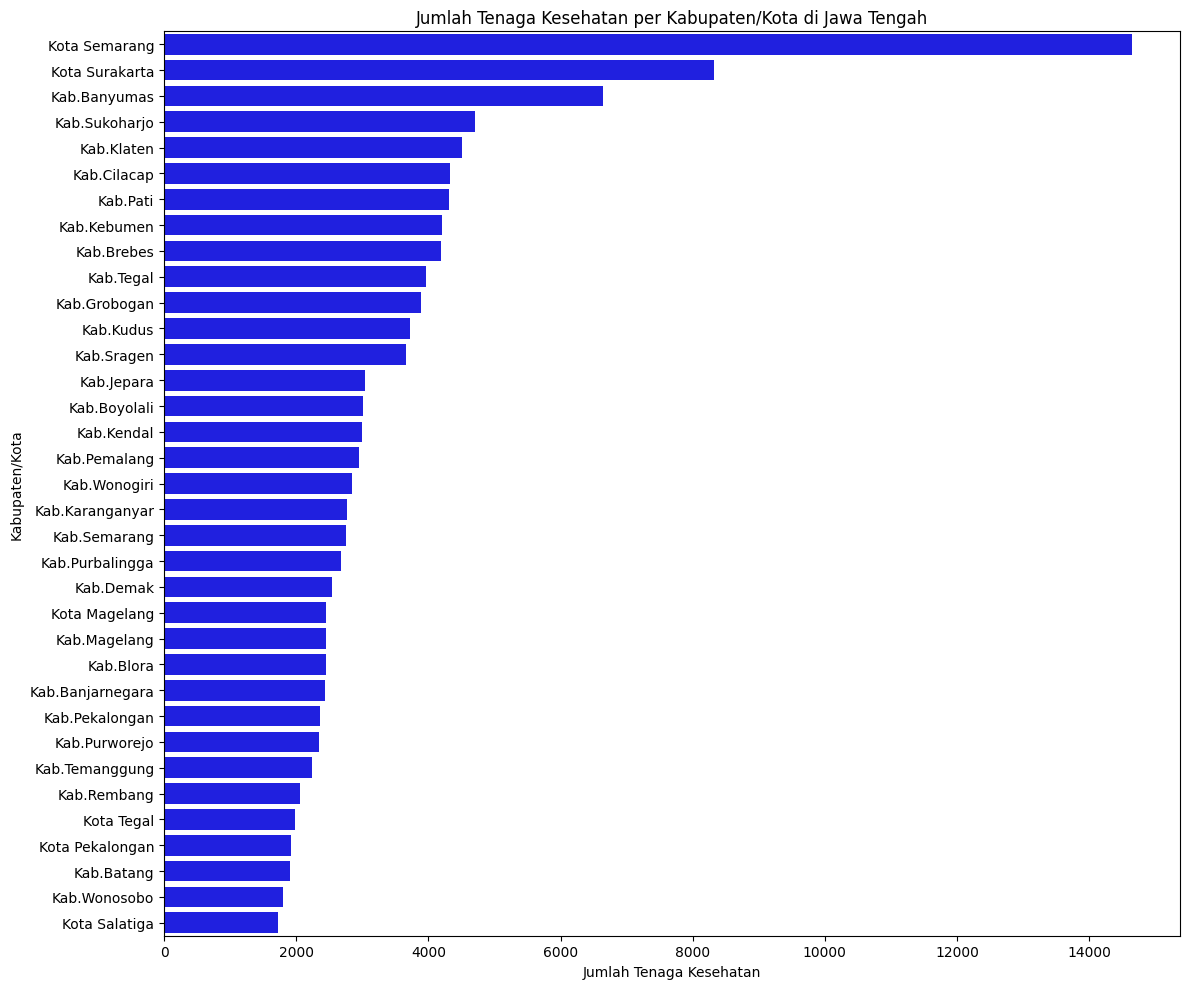

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter agar baris 'Total' tidak ikut ditampilkan
df_kab = df[df['kabupaten_kota'] != 'Total']

# Visualisasi total tenaga kesehatan per kabupaten/kota
plt.figure(figsize=(12, 10))  # ukuran figure

df_sorted = df_kab.sort_values('total_tenaga', ascending=False)  # urutkan descending

# Plot barplot satu warna saja
sns.barplot(
    y='kabupaten_kota',  # sumbu vertikal: nama daerah
    x='total_tenaga',    # sumbu horizontal: jumlah tenaga
    data=df_sorted,      # data yang sudah diurutkan
    color='blue'      # warna biru lembut untuk semua bar
)

plt.title('Jumlah Tenaga Kesehatan per Kabupaten/Kota di Jawa Tengah')  # judul grafik
plt.xlabel('Jumlah Tenaga Kesehatan')  # label sumbu X
plt.ylabel('Kabupaten/Kota')  # label sumbu Y
plt.tight_layout()  # rapikan tampilan
plt.show()  # tampilkan grafik


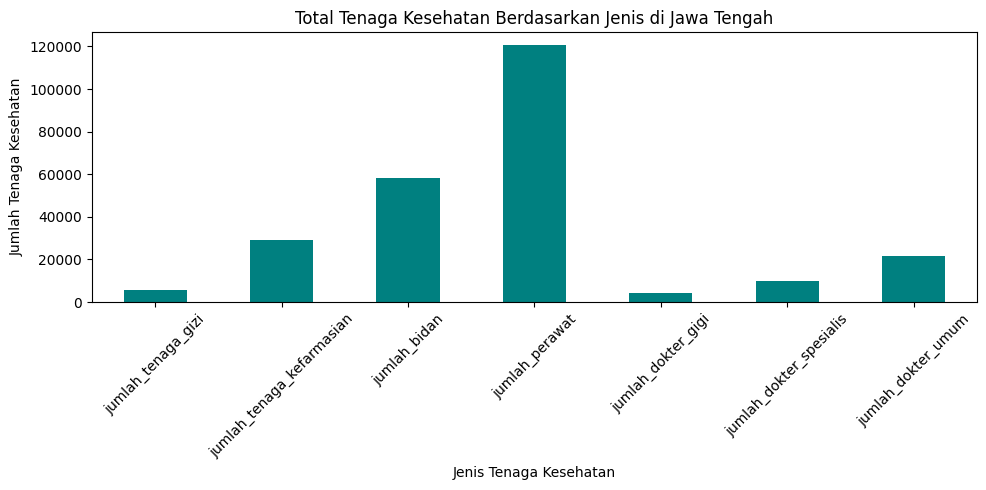

In [ ]:
# Visualisasi perbandingan jenis tenaga kesehatan
plt.figure(figsize=(10, 5))                               # ukuran grafik
total_per_jenis.plot(kind='bar', color='teal')            # buat grafik batang dengan warna teal
plt.title('Total Tenaga Kesehatan Berdasarkan Jenis di Jawa Tengah')  # judul grafik
plt.ylabel('Jumlah Tenaga Kesehatan')                     # label sumbu Y
plt.xlabel('Jenis Tenaga Kesehatan')                      # label sumbu X
plt.xticks(rotation=45)                                   # miringkan label X agar terbaca
plt.tight_layout()                                        # rapikan tata letak grafik
plt.show()                                                # tampilkan grafik

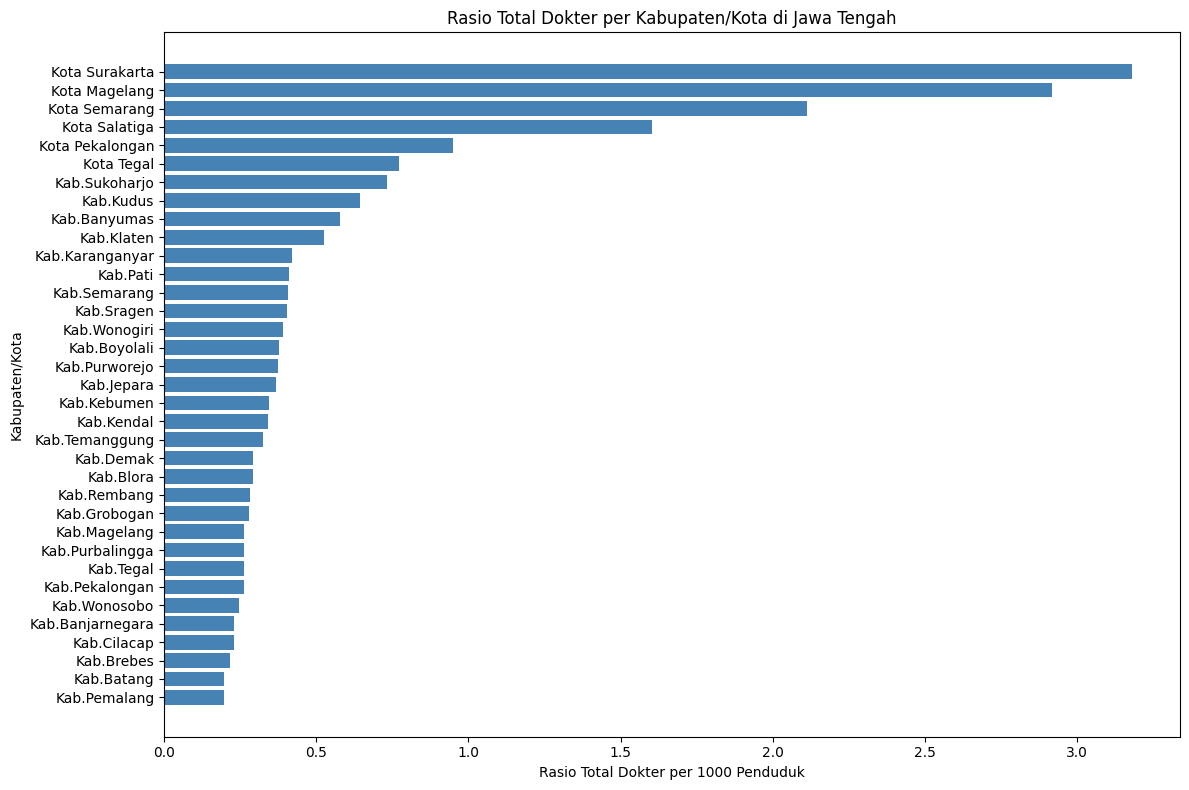

In [ ]:
df_kab = df[df['kabupaten_kota'] != 'Total']  # hapus baris total agar grafik bersih
df_sorted = df_kab.sort_values('rasio_total_dokter', ascending=False)  # urutkan dari rasio tertinggi

plt.figure(figsize=(12, 8))  # ukuran grafik
plt.barh(df_sorted['kabupaten_kota'], df_sorted['rasio_total_dokter'], color='steelblue')  # bar horizontal
plt.xlabel('Rasio Total Dokter per 1000 Penduduk')  # label sumbu X
plt.ylabel('Kabupaten/Kota')  # label sumbu Y
plt.title('Rasio Total Dokter per Kabupaten/Kota di Jawa Tengah')  # judul grafik
plt.gca().invert_yaxis()  # urutkan dari atas ke bawah
plt.tight_layout()  # rapikan tata letak
plt.show()  # tampilkan grafik

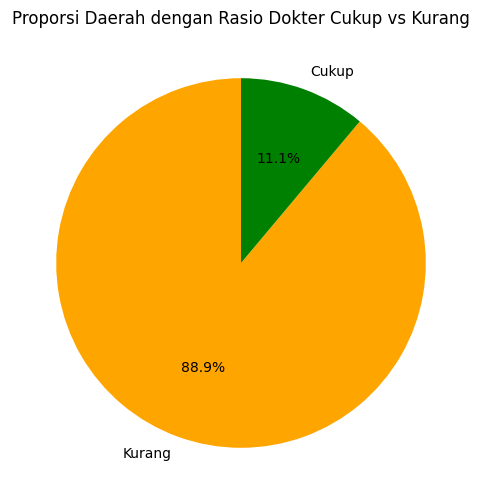

In [ ]:
plt.figure(figsize=(6, 6))  # ukuran grafik
plt.pie(summary_dokter, labels=summary_dokter.index, autopct='%1.1f%%', colors=['orange', 'green'], startangle=90)  # pie chart
plt.title('Proporsi Daerah dengan Rasio Dokter Cukup vs Kurang')  # judul grafik
plt.show()  # tampilkan grafik

In [ ]:
# Tampilkan DataFrame kabupaten/kota dengan rasio dokter cukup
df_cukup = df[df['rasio_total_dokter'] >= threshold_dokter][['kabupaten_kota', 'jumlah_penduduk', 'total_dokter', 'rasio_total_dokter']]

df_cukup  # menampilkan tabel


,kabupaten_kota,jumlah_penduduk,total_dokter,rasio_total_dokter
29,Kota Magelang,121675,355,2.917608
30,Kota Surakarta,523008,1663,3.179684
31,Kota Salatiga,195065,313,1.604593
32,Kota Semarang,1659975,3508,2.113285


# 6️⃣ Draw Conclusion & Communicate

Kesimpulan:

* Total tenaga kesehatan di Jawa Tengah: 124.757 orang untuk 37 juta penduduk.

* Jenis tenaga terbanyak: perawat (120.582) dan bidan (58.024).

* Jenis tenaga paling sedikit: dokter gigi (4.370) dan dokter spesialis (10.010).

* 32 dari 36 kabupaten/kota kekurangan dokter (<1 dokter per 1.000 penduduk).

* Hanya 4 kota besar (Magelang, Surakarta, Salatiga, Semarang) yang mencukupi dokter.

* Distribusi dokter tidak merata; kabupaten cenderung kekurangan dokter dibanding kota besar.

Saran:

1. Tingkatkan jumlah dokter di kabupaten kekurangan.

2. Perkuat fasilitas kesehatan di daerah terpencil.

3. Optimalkan peran perawat dan bidan untuk mendukung pelayanan.

4. Pantau distribusi tenaga kesehatan melalui sistem dashboard terpadu.